# Tank Anomaly Detection Pipeline
**Dataset:** Physical Refinery — 6 Tanks (physical_01 to physical_06)  
**Model:** Isolation Forest  
**Interval:** 1 reading per minute

## Install Dependencies

In [ ]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

## Imports & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

CSV_FILE        = 'physical_refinery_dataset.csv'
MAX_FT          = 25.0
W               = 60      # 60 readings x 1 min = 1 hour
SPIKE_THRESHOLD = 1.5     # max ft change per 1-min reading
Z_THRESHOLD     = 4       # z-score beyond this = anomaly

print('Config ready')
print(f'MAX_FT={MAX_FT}, W={W}, SPIKE={SPIKE_THRESHOLD}, Z={Z_THRESHOLD}')

Config ready
MAX_FT=25.0, W=60, SPIKE=1.5, Z=4


---
## Step 1 — Load Dataset

In [ ]:
df = pd.read_csv(CSV_FILE)
df = df.rename(columns={
    'Date Time'             : 'datetime',
    'TankOilLevelInFeet001' : 'level_feet',
    'Physical Refinery'     : 'tank_id'
})
df['level_feet'] = pd.to_numeric(df['level_feet'], errors='coerce')
print(f'Rows: {len(df):,} | Tanks: {sorted(df["tank_id"].unique())}')
df.head()

Rows: 54,646 | Tanks: ['physical_01', 'physical_02', 'physical_03', 'physical_04', 'physical_05', 'physical_06']


,datetime,level_feet,tank_id
0,06:59 PM - 14/03/2026,25.131234,physical_01
1,06:58 PM - 14/03/2026,25.131234,physical_01
2,06:57 PM - 14/03/2026,25.131234,physical_01
3,06:56 PM - 14/03/2026,25.131234,physical_01
4,06:55 PM - 14/03/2026,25.131234,physical_01


In [ ]:
df.groupby('tank_id')['level_feet'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
tank_id,,,,,,,,
physical_01,9225.0,24.238,2.258,17.620,25.000,25.000,25.000,25.131
physical_02,9185.0,12.091,4.262,1.200,9.777,11.647,13.900,25.000
physical_03,8876.0,9.335,5.181,6.100,6.200,7.185,9.974,25.000
physical_04,9032.0,18.989,4.994,1.870,18.000,18.650,20.801,26.115
physical_05,9049.0,22.101,3.732,1.000,22.867,23.400,23.600,25.525
physical_06,9259.0,15.096,3.505,3.412,11.877,14.403,16.864,73.163


---
## Step 2 — Parse Mixed Datetime Formats
- Format 1: `06:59 PM - 14/03/2026`
- Format 2: `12/3/2026 23:59`

In [ ]:
def parse_dt(val):
    val = str(val).strip()
    for fmt in [
        '%I:%M %p - %d/%m/%Y',
        '%m/%d/%Y %H:%M',
        '%d/%m/%Y %H:%M',
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%d %H:%M',
    ]:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            continue
    return pd.NaT

df['datetime'] = df['datetime'].apply(parse_dt)
failed = df['datetime'].isna().sum()
print(f'Parsed OK: {len(df)-failed:,} | Failed: {failed}')
df = df.dropna(subset=['datetime'])
df = df.sort_values(['tank_id','datetime']).reset_index(drop=True)
print(f'Date range: {df["datetime"].min()} to {df["datetime"].max()}')

Parsed OK: 54,646 | Failed: 0
Date range: 2026-03-07 19:00:00 to 2026-12-03 23:59:00


---
## Step 3 — Clean Bad Level Values

In [ ]:
df['is_bad'] = 0
df.loc[df['level_feet'].isna(),     'is_bad'] = 1
df.loc[df['level_feet'] < 0,        'is_bad'] = 1
df.loc[df['level_feet'] > 30,       'is_bad'] = 1

df['prev_level'] = df.groupby('tank_id')['level_feet'].shift(1)
df.loc[(df['level_feet']==0)&(df['prev_level']>1), 'is_bad'] = 1

df['roc_raw'] = df.groupby('tank_id')['level_feet'].diff().abs()
df.loc[df['roc_raw'] > SPIKE_THRESHOLD, 'is_bad'] = 1

df.loc[df['is_bad']==1, 'level_feet'] = np.nan
df['level_feet'] = (
    df.groupby('tank_id')['level_feet']
      .transform(lambda x: x.interpolate(method='linear', limit=10))
)
df['level_feet'] = (
    df.groupby('tank_id')['level_feet']
      .transform(lambda x: x.fillna(x.mean()))
)
print(f'Bad readings fixed: {df["is_bad"].sum():,}')
df.groupby('tank_id')['is_bad'].sum().rename('bad_count')

Bad readings fixed: 352


,bad_count
tank_id,
physical_01,7
physical_02,11
physical_03,8
physical_04,11
physical_05,145
physical_06,170


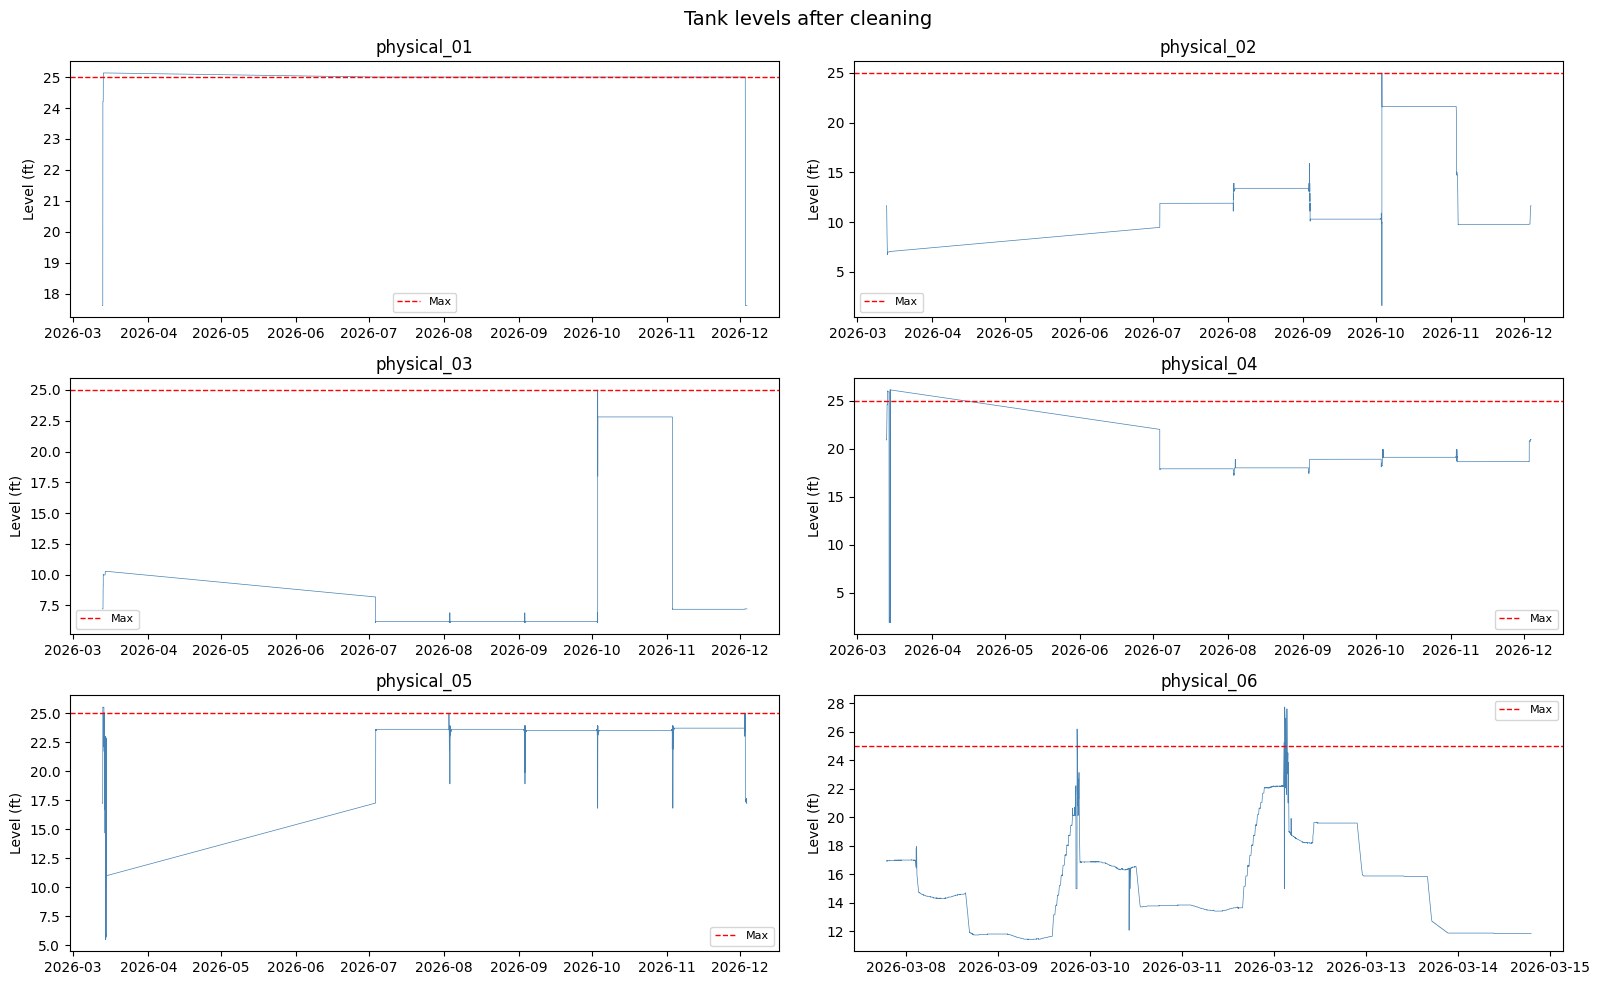

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()
for i, (tank, group) in enumerate(df.groupby('tank_id')):
    axes[i].plot(group['datetime'], group['level_feet'], linewidth=0.5, color='steelblue')
    axes[i].axhline(y=MAX_FT, color='red', linestyle='--', linewidth=1, label='Max')
    axes[i].set_title(tank, fontsize=12)
    axes[i].set_ylabel('Level (ft)')
    axes[i].legend(fontsize=8)
plt.suptitle('Tank levels after cleaning', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 4 — Feature Engineering
Generates 16 features from just 2 columns (datetime + level_feet)

In [ ]:
feature_parts = []
for tank_id, group in df.groupby('tank_id'):
    g = group.copy()
    g['headspace']     = MAX_FT - g['level_feet']
    g['fill_pct']      = (g['level_feet'] / MAX_FT) * 100
    g['roc']           = g['level_feet'].diff()
    g['roc_abs']       = g['roc'].abs()
    g['accel']         = g['roc'].diff()
    g['roll_mean']     = g['level_feet'].rolling(W, min_periods=1).mean()
    g['roll_std']      = g['level_feet'].rolling(W, min_periods=1).std().fillna(0)
    g['roll_min']      = g['level_feet'].rolling(W, min_periods=1).min()
    g['roll_max']      = g['level_feet'].rolling(W, min_periods=1).max()
    g['roll_range']    = g['roll_max'] - g['roll_min']
    g['dev_from_mean'] = g['level_feet'] - g['roll_mean']
    mu                 = g['level_feet'].mean()
    sig                = g['level_feet'].std() + 1e-9
    g['z_score']       = (g['level_feet'] - mu) / sig
    g['hour']          = g['datetime'].dt.hour
    g['minute']        = g['datetime'].dt.minute
    g['day_of_week']   = g['datetime'].dt.dayofweek
    g['is_night']      = ((g['hour']>=22)|(g['hour']<=5)).astype(int)
    g['tank_id']       = tank_id
    feature_parts.append(g)

df = pd.concat(feature_parts, ignore_index=True)
df = df.fillna(0)
print(f'Shape: {df.shape}')
df[['tank_id','level_feet','headspace','roc','z_score','hour']].head()

Shape: (54646, 22)


,tank_id,level_feet,headspace,roc,z_score,hour
0,physical_01,17.62,7.38,0.0,-2.93292,0
1,physical_01,17.62,7.38,0.0,-2.93292,0
2,physical_01,17.62,7.38,0.0,-2.93292,0
3,physical_01,17.62,7.38,0.0,-2.93292,0
4,physical_01,17.62,7.38,0.0,-2.93292,0


---
## Step 5 — Label Anomalies (Rule-Based)

In [ ]:
df['label'] = 0
df.loc[df['level_feet'] < 0,                    'label'] = 1
df.loc[df['level_feet'] > 30,                   'label'] = 1
df.loc[(df['level_feet']==0)&(df['roc_abs']>1), 'label'] = 1
df.loc[df['roc_abs']       > SPIKE_THRESHOLD,   'label'] = 1
df.loc[df['z_score'].abs() > Z_THRESHOLD,       'label'] = 1

le = LabelEncoder()
df['tank_enc'] = le.fit_transform(df['tank_id'])

print('Tank encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
summary = df.groupby('tank_id').agg(
    total=('label','count'), anomaly=('label','sum')
).assign(pct=lambda x: (x['anomaly']/x['total']*100).round(2))
summary

Tank encoding: {'physical_01': np.int64(0), 'physical_02': np.int64(1), 'physical_03': np.int64(2), 'physical_04': np.int64(3), 'physical_05': np.int64(4), 'physical_06': np.int64(5)}


,total,anomaly,pct
tank_id,,,
physical_01,9230,4,0.04
physical_02,9188,13,0.14
physical_03,8879,10,0.11
physical_04,9036,11,0.12
physical_05,9054,238,2.63
physical_06,9259,13,0.14


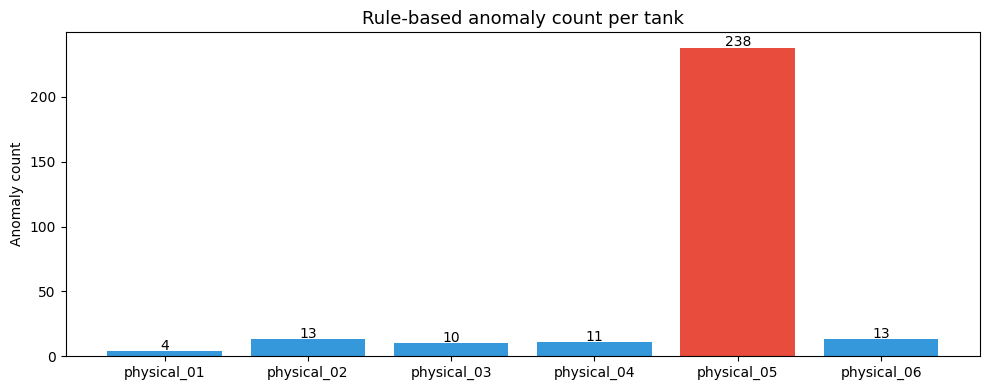

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 1 else '#3498db' for v in summary['pct']]
bars = ax.bar(summary.index, summary['anomaly'], color=colors)
ax.set_title('Rule-based anomaly count per tank', fontsize=13)
ax.set_ylabel('Anomaly count')
for bar, val in zip(bars, summary['anomaly']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Step 6 — Train Isolation Forest

In [ ]:
FEATURES = [
    'level_feet',    'headspace',     'fill_pct',
    'roc',           'roc_abs',       'accel',
    'roll_mean',     'roll_std',      'roll_range',
    'dev_from_mean', 'z_score',       'hour',
    'minute',        'day_of_week',   'is_night',
    'tank_enc'
]

train_df = df[df['label']==0][FEATURES].dropna()
contamination = round(float(np.clip(df['label'].sum()/len(df), 0.01, 0.15)), 4)

print(f'Training rows : {len(train_df):,}')
print(f'Anomaly rows  : {df["label"].sum():,} excluded')
print(f'Contamination : {contamination}')

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df)

model = IsolationForest(
    n_estimators  = 200,
    contamination = contamination,
    random_state  = 42,
    n_jobs        = -1
)
model.fit(X_train)
print('Model trained!')

Training rows : 54,357
Anomaly rows  : 289 excluded
Contamination : 0.01
Model trained!


---
## Step 7 — Predict & Save

In [ ]:
X_all            = scaler.transform(df[FEATURES].fillna(0))
df['score']      = model.decision_function(X_all)
df['is_anomaly'] = (model.predict(X_all)==-1).astype(int)

joblib.dump(model,  'tank_model.pkl')
joblib.dump(scaler, 'tank_scaler.pkl')
joblib.dump(le,     'tank_encoder.pkl')

df[['datetime','tank_id','level_feet','fill_pct',
    'headspace','roc','z_score','score',
    'is_anomaly','label']].to_csv('tank_predictions.csv', index=False)

print('Saved: tank_model.pkl, tank_scaler.pkl, tank_encoder.pkl')
print('Saved: tank_predictions.csv')

Saved: tank_model.pkl, tank_scaler.pkl, tank_encoder.pkl
Saved: tank_predictions.csv


---
## Step 8 — Final Report & Visualizations

In [ ]:
report = df.groupby('tank_id').agg(
    total_readings  = ('level_feet', 'count'),
    avg_level_ft    = ('level_feet', 'mean'),
    rule_anomalies  = ('label',      'sum'),
    model_anomalies = ('is_anomaly', 'sum'),
    avg_score       = ('score',      'mean')
).round(3)
report

,total_readings,avg_level_ft,rule_anomalies,model_anomalies,avg_score
tank_id,,,,,
physical_01,9230,24.238,4,4,0.195
physical_02,9188,12.089,13,65,0.177
physical_03,8879,9.334,10,58,0.177
physical_04,9036,18.989,11,231,0.191
physical_05,9054,22.117,238,238,0.175
physical_06,9259,14.985,13,107,0.179


In [ ]:
print('Top 10 most anomalous readings:')
df[df['is_anomaly']==1].nsmallest(10,'score')[
    ['datetime','tank_id','level_feet','roc','z_score','score']
]

Top 10 most anomalous readings:


,datetime,tank_id,level_feet,roc,z_score,score
28668,2026-03-14 01:40:00,physical_04,1.902887,-12.007874,-3.426556,-0.120652
29518,2026-03-14 17:05:00,physical_04,26.115486,12.122704,1.429058,-0.117009
24250,2026-10-03 10:25:00,physical_03,19.250000,-5.750000,1.914994,-0.115748
15263,2026-10-03 10:51:00,physical_02,23.295000,-1.705000,2.630763,-0.115466
29486,2026-03-14 16:27:00,physical_04,1.870079,-12.106300,-3.433136,-0.115321
38394,2026-03-14 13:04:00,physical_05,7.381890,1.279528,-3.968292,-0.111329
28683,2026-03-14 01:57:00,physical_04,1.870079,-0.032808,-3.433136,-0.103942
24259,2026-10-03 10:36:00,physical_03,18.005000,4.805000,1.674548,-0.101893
51295,2026-03-12 02:53:00,physical_06,25.645233,-1.224847,3.627029,-0.099642
38388,2026-03-14 12:58:00,physical_05,5.741470,-0.557743,-4.410084,-0.098765


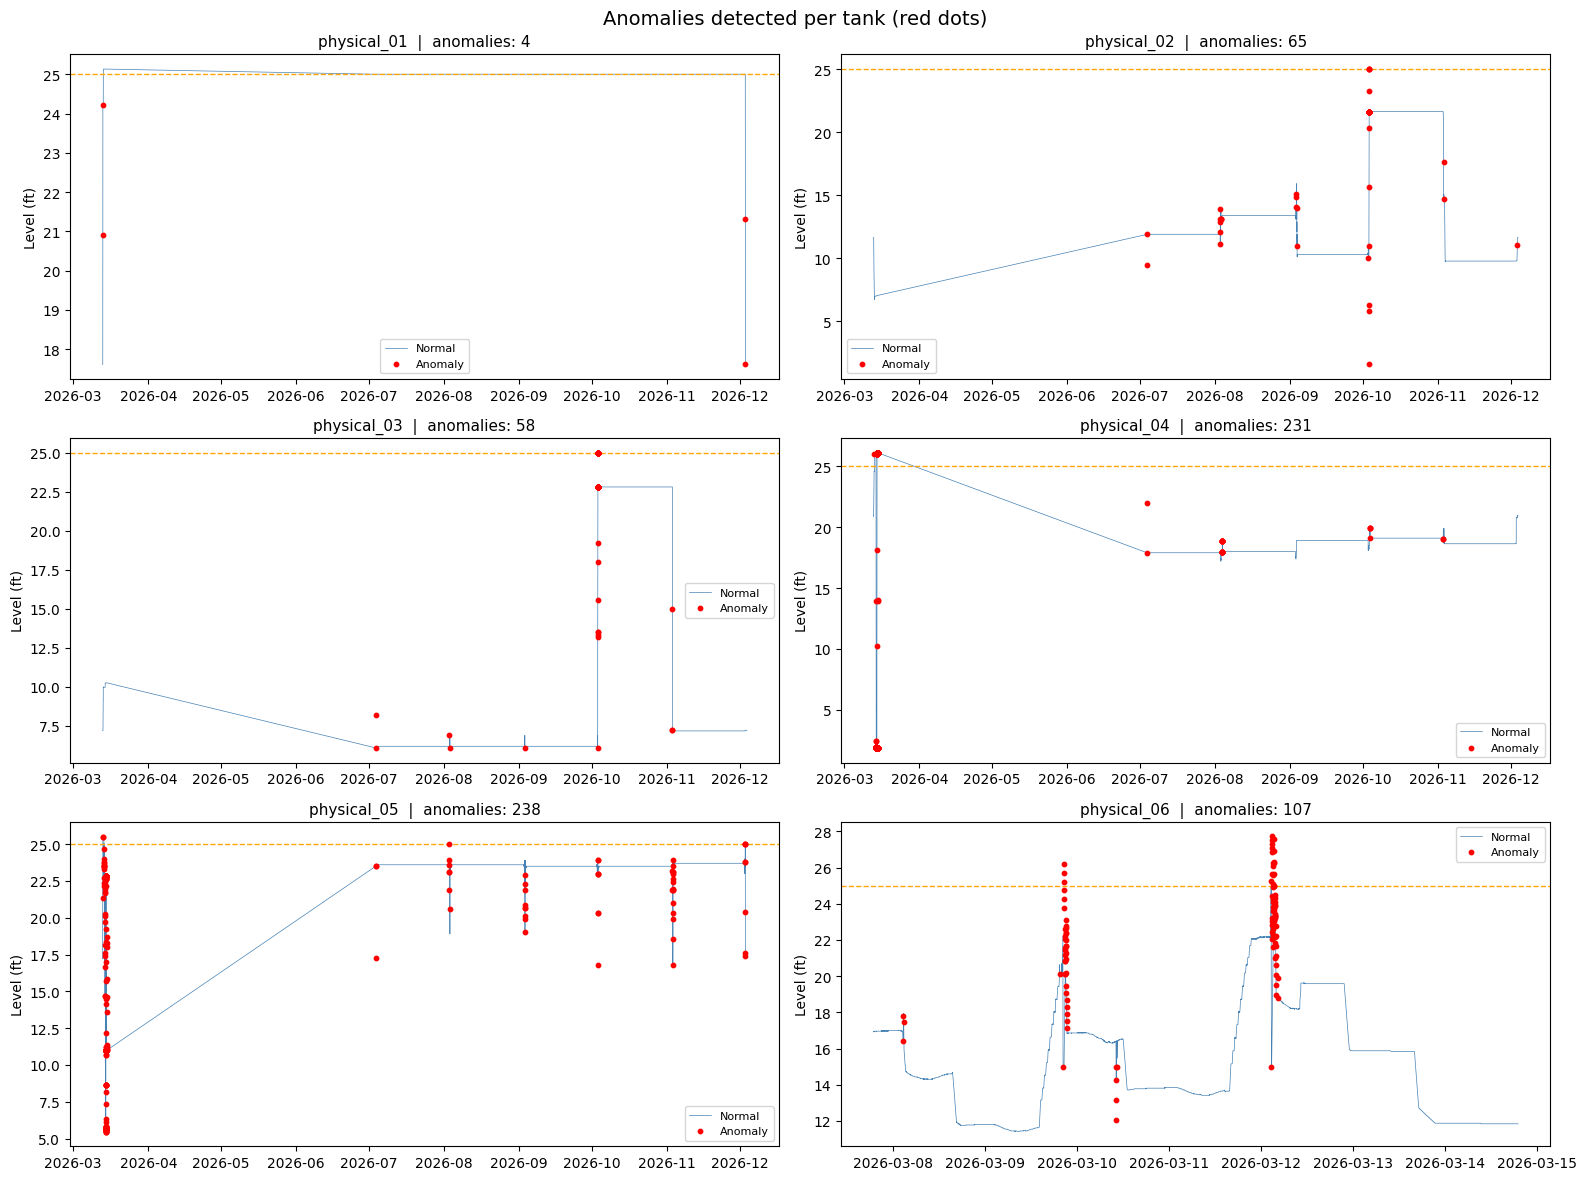

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
for i, (tank, group) in enumerate(df.groupby('tank_id')):
    normal  = group[group['is_anomaly']==0]
    anomaly = group[group['is_anomaly']==1]
    axes[i].plot(normal['datetime'],  normal['level_feet'],  color='steelblue', linewidth=0.5, label='Normal')
    axes[i].scatter(anomaly['datetime'], anomaly['level_feet'], color='red', s=10, zorder=5, label='Anomaly')
    axes[i].axhline(y=MAX_FT, color='orange', linestyle='--', linewidth=1)
    axes[i].set_title(f'{tank}  |  anomalies: {len(anomaly)}', fontsize=11)
    axes[i].set_ylabel('Level (ft)')
    axes[i].legend(fontsize=8)
plt.suptitle('Anomalies detected per tank (red dots)', fontsize=14)
plt.tight_layout()
plt.show()

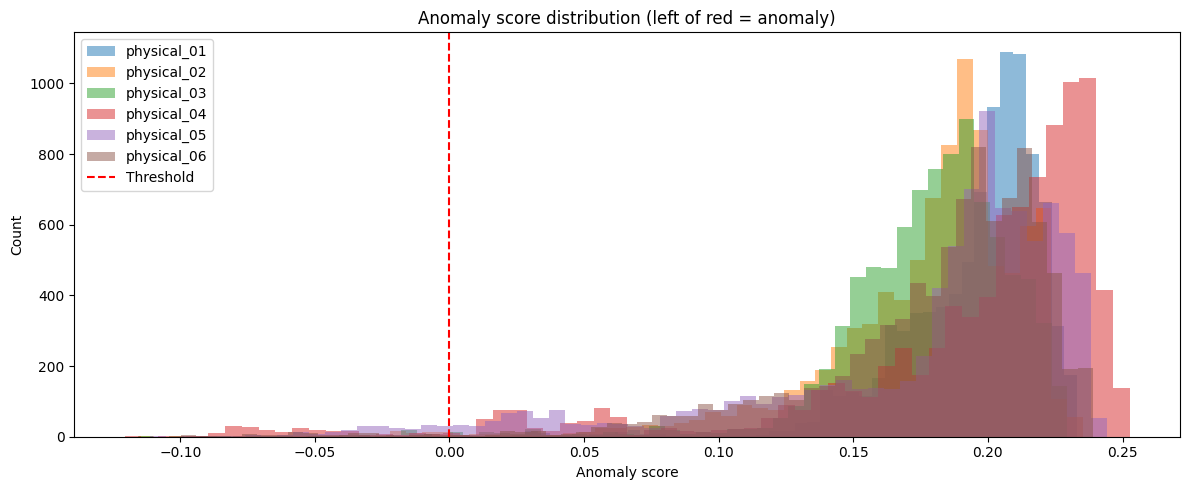

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for tank, group in df.groupby('tank_id'):
    ax.hist(group['score'], bins=60, alpha=0.5, label=tank)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Threshold')
ax.set_title('Anomaly score distribution (left of red = anomaly)', fontsize=12)
ax.set_xlabel('Anomaly score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

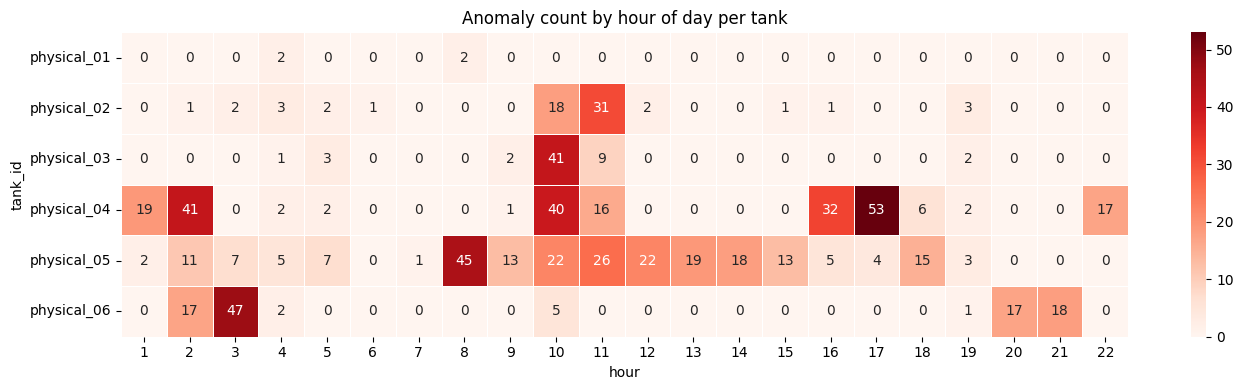

In [ ]:
pivot = df[df['is_anomaly']==1].groupby(['tank_id','hour']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap='Reds', linewidths=0.5, annot=True, fmt='d')
plt.title('Anomaly count by hour of day per tank', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 9 — Flask API for n8n
Save `app.py` and run `python app.py` to serve predictions.

In [ ]:
flask_code = '''
from flask import Flask, request, jsonify
import joblib, numpy as np

app    = Flask(__name__)
model  = joblib.load("tank_model.pkl")
scaler = joblib.load("tank_scaler.pkl")
le     = joblib.load("tank_encoder.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    d = request.json
    tank_enc = le.transform([d["tank_id"]])[0]
    X = scaler.transform([[
        d["level_feet"],    d["headspace"],     d["fill_pct"],
        d["roc"],           d["roc_abs"],       d["accel"],
        d["roll_mean"],     d["roll_std"],      d["roll_range"],
        d["dev_from_mean"], d["z_score"],       d["hour"],
        d["minute"],        d["day_of_week"],   d["is_night"],
        tank_enc
    ]])
    return jsonify({
        "tank_id"      : d["tank_id"],
        "anomaly_score": round(float(model.decision_function(X)[0]), 4),
        "is_anomaly"   : int(model.predict(X)[0] == -1)
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''
with open('app.py', 'w') as f:
    f.write(flask_code.strip())
print('Saved: app.py  |  Run with: python app.py')